In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

Our TTC streetcar data was pulled from TransSee using beautifulSoup. It is rather large, so they were pulled in chunks. Here we load them all:


In [2]:
import os
path_to_raw_files = '../data/raw_data/schedule_data/'
dataframes = [pd.read_csv(os.path.join(path_to_raw_files,x)) for x in os.listdir(path_to_raw_files) if x[-4:] == '.csv']
df_506=pd.concat(dataframes, ignore_index=True)
if 'Unnamed: 0' in df_506.columns:
    df_506.drop(columns=['Unnamed: 0'], inplace=True)
df_506.head()

/var/folders/6d/x65kjw5d1vl7fw7pnbx51yb80000gn/T/ipykernel_4960/749079354.py:3: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframes = [pd.read_csv(os.path.join(path_to_raw_files,x)) for x in os.listdir(path_to_raw_files) if x[-4:] == '.csv']
/var/folders/6d/x65kjw5d1vl7fw7pnbx51yb80000gn/T/ipykernel_4960/749079354.py:3: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframes = [pd.read_csv(os.path.join(path_to_raw_files,x)) for x in os.listdir(path_to_raw_files) if x[-4:] == '.csv']
/var/folders/6d/x65kjw5d1vl7fw7pnbx51yb80000gn/T/ipykernel_4960/749079354.py:3: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframes = [pd.read_csv(os.path.join(path_to_raw_files,x)) for x in os.listdir(path_to_raw_files) if x[-4:] == '.csv']
/var/folders/6d/x65kjw5d1vl7fw7pnbx51yb80000gn/T/ipykernel_4960/749079354.py:3: DtypeWarnin

,Time,Vehicle,Gap,Headway,Schedule,Destination,day,day of the week,Riders after stop
0,7:22:10AM,4574.0,NaN,8:20,2:36 ahead of 7:24:46AM,East to Main Street Station,2025-01-01,2,NaN
1,11:26:02PM,4552.0,12:51,10:00,1:53 ahead of 11:27:55PM,East to Main Street Station,2025-01-01,2,NaN
2,11:33:47PM,4591.0,7:46,10:00,14:08 ahead of 11:47:55PM,East to Main Street Station,2025-01-01,2,NaN
3,11:50:12PM,4575.0,16:24,10:00,12:17 behind 11:37:55PM,East to Main Street Station,2025-01-01,2,NaN
4,11:58:04PM,4629.0,7:52,10:00,0:09 behind 11:57:55PM,East to Main Street Station,2025-01-01,2,NaN


In [3]:
def calculate_delay(schedule_str:str|float) -> int|float:
    if type(schedule_str) != str:
        return schedule_str

    if 'ahead' in schedule_str:
        time_str = schedule_str.split(' ahead ')[0]
        time_list = time_str.split(':')

        if len( time_list ) == 2:
            time_list.insert(0, '0')

        return -( pd.Timedelta(hours=int(time_list[0]), minutes=int(time_list[1] ), seconds= int( time_list[2] ) ).total_seconds()/60 )
    elif 'behind' in schedule_str:
        time_str = schedule_str.split(' behind ')[0]
        time_list = time_str.split(':')

        if len( time_list ) == 2:
            time_list.insert(0, '0')

        return ( pd.Timedelta(hours=int(time_list[0]), minutes=int(time_list[1] ), seconds= int( time_list[2] ) ).total_seconds()/60 )
    else:
        return 0


From the provided entries, we add a "datetime" column, which is just combining the date and time information. We also include a "schedule adherence" column, which is calculated from the provided "Schedule" column. If a streetcar was reported %M:%S minutes behind schedule, then that delay time is recorded in the "schedule adherence" column as a time delta object. If a streetcar was reported %M:%S minutes ahead of schedule, then that time is recorded as time delta object, with a negative sign

In [4]:
df_506['Time'] = df_506['Time'].apply( (lambda x : pd.to_datetime(x[:10]) ))
df_506['datetime'] = df_506['day'].astype(str)  + ' '+  df_506['Time'].apply( lambda x : x.strftime( "%H:%M:%S"))
df_506['sch_adherence'] = df_506['Schedule'].apply(calculate_delay)

In this dataset, the entry "Gap" records the observed time between successive streetcars at a particular stop. This is opposed to the column "Headway", which records the scheduled gap between successive streetcars. The "Gap" column is entered as a string, so we must convert these entries to pd.Timedelta objects 

In [5]:
df_506['Gap'] = df_506['Gap'].apply(lambda x : pd.Timedelta( minutes = int( x.split(':')[0] ), seconds= int( x.split(':')[1] )  ) if type(x) == str else x )

Steve Munro runs a great transit blog (https://stevemunro.ca/), which is even mostly specific to understanding the TTC. He has a good selection of blog posts regarding "bunching" and "gapping". Bunching happens when streetcars appear at a stop in quick succession (i.e. when a streetcar arrives at a stop much below the scheduled headway time), and gapping happens when a streetcar arrives at a stop much above the scheduled headway time. In the post (https://stevemunro.ca/2025/11/02/ttc-bunching-and-gapping-pilot/), Steve suggests that for routes with 10 minute scheduled headway times reasonable definitions of bunching and gapping could be: 1) bunching is when streetcars arrive at a stop <= 2-minutes apart from each other and  2) gapping is when streetcars arrive at a stop >= 19 minutes apart from each other 

In [6]:
def bunched_or_gapped( td , mins = (2,19)):
    if td < pd.Timedelta( minutes = mins[0]):
        return -1
    elif td > pd.Timedelta(minutes  = mins[1]):
        return 1
    else: 
        return 0 

In [7]:
df_506['bunched_or_gapped'] = df_506['Gap'].apply(bunched_or_gapped)

In [8]:
df_506['mins delayed'] = df_506['sch_adherence'].apply(lambda x : max(x,0))

In [10]:
df_506['bunched'] = df_506['bunched_or_gapped'].apply( lambda x : 1 if x == -1 else 0 )
df_506['gapped'] = df_506['bunched_or_gapped'].apply( lambda x : 1 if x == 1 else 0 )

We need to prune long streaks of no reported gap. That is, long streaks where the streetcar was perfectly on time. Given the scale of the dataset (it records even a 30 second delay), it is safe to assume that a long streak of no gap information implies that the stop was actually not in service. Unfortunately, the dataset does include periods of time when a stop was not being used. In this case, the data will appear as if the streetcar was on time for every scheduled arrival.

In [9]:
n= 25
s= df_506.Gap.isnull().groupby(df_506.Gap.isnull().astype(int).diff().ne(0).cumsum()).transform('count')
df_506 = df_506.loc[~((s>n)&(df_506.Gap.isnull()))]

According to the TTC, the schedule is divided into "time categories" (caveat: these categories are slightly different for the weekends, but we can leave them as is for now). The categories are:

- 'Morning peak': 6am - 9am,
- 'Midday': 9am - 3pm,
- 'Afternoon peak': 3pm - 7pm,
- 'Early evening': 7pm - 10pm,
- 'Late evening': 10pm - 1am,
- 'Overnight': 130am- 530am



We will stratify our recorded bunching and gapping incidents into the respective time category when the incident occured.

In [11]:
time_cats_enc = { 0: (pd.Timedelta(hours=6), pd.Timedelta(hours=9)),
                  1 : (pd.Timedelta(hours=9), pd.Timedelta(hours=15)),
                  2: (pd.Timedelta(hours=15), pd.Timedelta(hours=19)),
                  3: (pd.Timedelta(hours=19), pd.Timedelta(hours=22)),
                  4: (pd.Timedelta(hours=22), pd.Timedelta(hours=1, days=1)),
                  5: (pd.Timedelta(minutes=30, hours=1, days=1), pd.Timedelta(minutes=30, hours=5, days=1))
                  }

In [12]:
def is_time_in_range(start_time, end_time, checked_time):
    if end_time < start_time: # Range spans midnight
        return ( pd.Timestamp('12am') <= checked_time < end_time ) or ( start_time <= checked_time < pd.Timestamp('12am') )
        
    else: # Range within the same day
        return start_time <= checked_time < end_time
    
def which_timecat(x):
    for key in time_cats_enc:
        if is_time_in_range( time_cats_enc[key][0], time_cats_enc[key][1], pd.Timestamp(x.time().strftime( '%H:%M:%S')) ):
            return key    

In [13]:
df_506['Time'] = df_506['Time'].apply( lambda x : pd.Timedelta( hours=x.hour,minutes=x.minute, seconds=x.second)  )

In [14]:
time_periods = ['morning_peak', 'midday', 'afternoon_peak', 'early_eve', 'late_eve', 'overnight']
for idx, period in enumerate(time_periods):
    df_506[period] = df_506['Time'].apply( lambda x : time_cats_enc[idx][0] <= x < time_cats_enc[idx][1] ).astype(int)

In [15]:
time_periods = ['morning_peak', 'midday', 'afternoon_peak', 'early_eve', 'late_eve']
for period in time_periods:
    df_506[f'{period}_bunches'] = (df_506[period]*df_506['bunched'])
    df_506[f'{period}_gaps'] = (df_506[period]*df_506['gapped'])

We will also add to our model the recorded centimeters of snow on the ground for a given day, and the number of alerts in the TTC system issued for the 506 streetcar that are classified as an "disruptive event" (delay notice, stop closure..etc) for a given day

In [16]:
alerts_df = pd.read_csv('ttc_506_notices_2025_structured_from_extended.csv')
# alerts_df.rename( columns = { 0 : 'num_alerts' })
alertsday = alerts_df[ alerts_df['notice_status'] == 'disruption'].groupby('date').size()


In [17]:
weather_2025 = pd.read_csv('../data/raw_data/Weatherstats_data/weatherstats_toronto_daily.csv')
weather_df = weather_2025.iloc[:197]
snow_on_ground = weather_df[['date','snow_on_ground']]
snow_on_ground = snow_on_ground.fillna(0)

Now we organize our dataframe by day. In the end, the target of our model will be the number of accumulated minutes of delay each day. We truncate the data to looking at recorded delays of under 2 hours to account for reporting inconsistencies (a cancelled streetcar may appear as a very long delay).
 

In [18]:
byday_506 = df_506[ df_506['mins delayed'] < 120 ][['day', 'mins delayed','bunched','gapped', 'morning_peak_bunches', 'midday_bunches', 'afternoon_peak_bunches', 'early_eve_bunches', 'late_eve_bunches', 'morning_peak_gaps', 'midday_gaps', 'afternoon_peak_gaps', 'early_eve_gaps', 'late_eve_gaps']].groupby(by='day').sum()

We merge the TTC alerts and snow data with our byday_506 dataframe. Pruning null rows that were introduced by merging..

In [19]:
byday_506  =  pd.merge( byday_506.reset_index(), weather_df.rename( columns={'date': 'day'})[['day','snow_on_ground']] , on='day', how = 'left') 
byday_506  = pd.merge( byday_506 , alertsday.reset_index().rename( columns={'date': 'day', 0: 'num_alerts'}), on='day' , how='left').set_index('day')


n= 3
s= byday_506['mins delayed'].isnull().groupby(byday_506['mins delayed'].isnull().astype(int).diff().ne(0).cumsum()).transform('count')
byday_506 = byday_506 .loc[~((s>n)&(byday_506['mins delayed'].isnull()))]
byday_506  = byday_506.fillna(0)

In [20]:
byday_506

,mins delayed,bunched,gapped,morning_peak_bunches,midday_bunches,afternoon_peak_bunches,early_eve_bunches,late_eve_bunches,morning_peak_gaps,midday_gaps,afternoon_peak_gaps,early_eve_gaps,late_eve_gaps,snow_on_ground,num_alerts
day,,,,,,,,,,,,,,,
2025-01-01,3879.383333,508,321,15,158,120,114,70,0,89,72,61,87,0.0,2.0
2025-01-02,3186.300000,304,403,56,90,21,85,45,56,110,47,102,19,0.0,0.0
2025-01-03,3919.283333,284,489,51,41,31,56,81,51,119,96,34,85,0.0,0.0
2025-01-04,4186.916667,324,394,114,81,48,22,26,127,82,27,15,0,0.0,3.0
2025-01-05,10062.450000,483,468,80,212,95,64,13,16,194,110,44,24,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-15,2535.800000,459,337,43,45,75,117,62,30,51,98,50,43,5.0,1.0
2025-12-16,4383.283333,436,402,59,61,35,85,54,52,124,88,24,34,3.0,0.0
2025-12-17,10117.066667,352,733,17,33,35,102,85,54,213,210,113,107,3.0,3.0


Let us take a look at the correlation between bunching incidents and total minutes delayed. 

<Axes: xlabel='bunched', ylabel='mins delayed'>

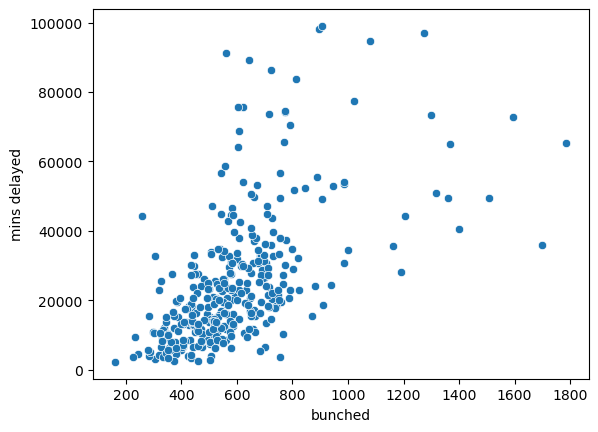

In [21]:
sns.scatterplot(byday_506, x='bunched', y='mins delayed')

Here we see that to up to a certain range for minutes delayed and bunching incidents, there is perhaps a fairly strong linear correlation. The outlier points perhaps indicate that there may be extraneous signal to model that can account for the difference in trend. 

<Axes: xlabel='bunched', ylabel='mins delayed'>

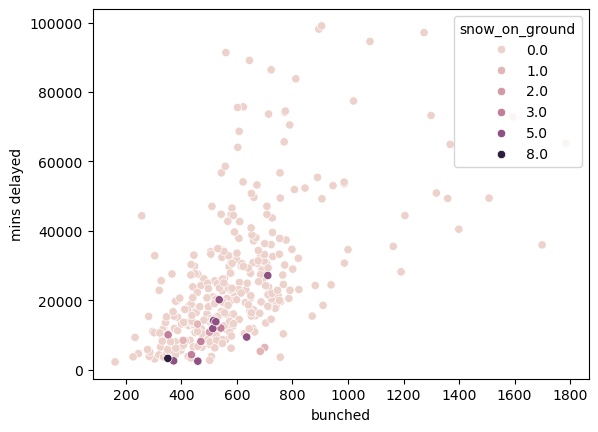

In [22]:
sns.scatterplot(byday_506, x='bunched', y='mins delayed', hue='snow_on_ground')

<Axes: xlabel='bunched', ylabel='mins delayed'>

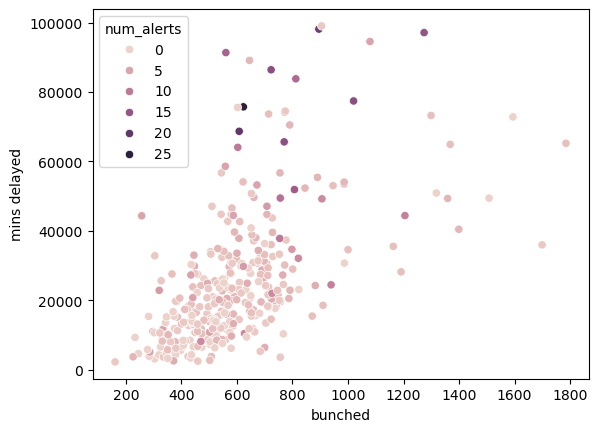

In [23]:
sns.scatterplot(byday_506, x='bunched', y='mins delayed', hue='num_alerts')

We can look at the bunching incidents split into respective time categories. We see that the rough linear relationships appear to be more or less the same for each time category -- but they do appear to perhaps vary in slope at least a little bit. Perhaps we will see a marginal improvement on prediction error if we separate the bunching incidents into individual features. 

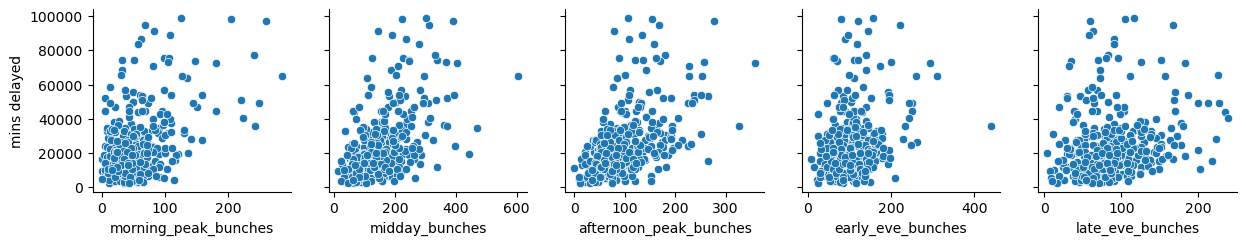

In [24]:
bunch_times = ['morning_peak_bunches', 'midday_bunches', 'afternoon_peak_bunches', 'early_eve_bunches', 'late_eve_bunches']


g = sns.PairGrid(byday_506, x_vars=bunch_times, y_vars=['mins delayed'])
g.map(sns.scatterplot)

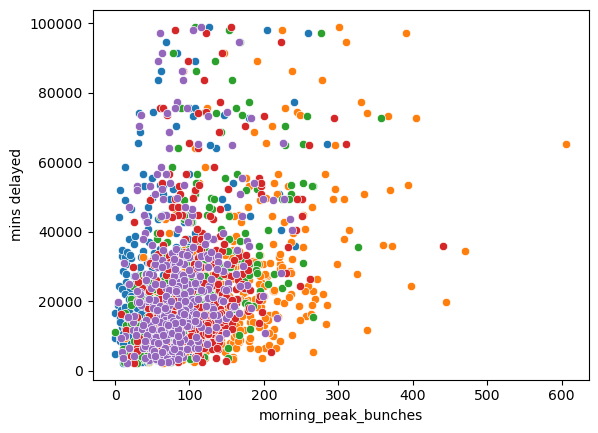

In [25]:
for bunch_time in bunch_times:
    sns.scatterplot(byday_506, x=bunch_time, y='mins delayed')

Let's consider the same analysis for gapping incidents. 

<Axes: xlabel='gapped', ylabel='mins delayed'>

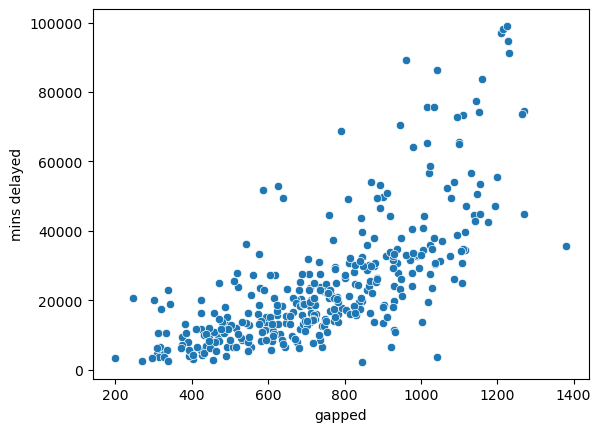

In [26]:
sns.scatterplot(byday_506, x='gapped', y='mins delayed')

<Axes: xlabel='gapped', ylabel='mins delayed'>

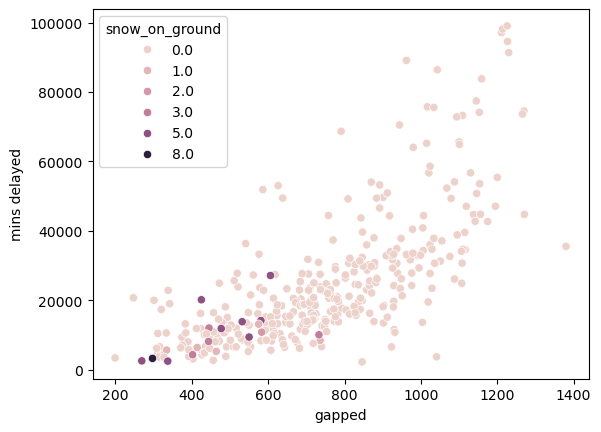

In [27]:
sns.scatterplot(byday_506, x='gapped', y='mins delayed',hue='snow_on_ground')


<Axes: xlabel='gapped', ylabel='mins delayed'>

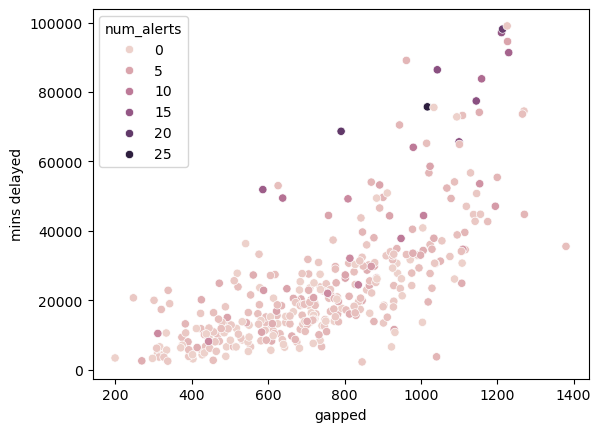

In [28]:
sns.scatterplot(byday_506, x='gapped', y='mins delayed',hue='num_alerts')


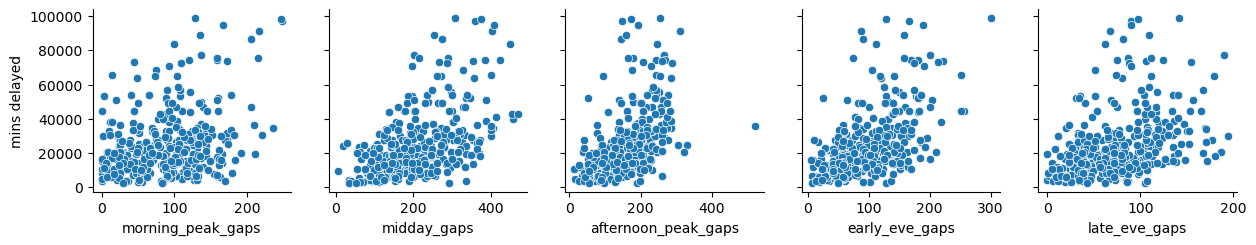

In [29]:
gap_times = ['morning_peak_gaps', 'midday_gaps', 'afternoon_peak_gaps', 'early_eve_gaps', 'late_eve_gaps']
g = sns.PairGrid(byday_506, x_vars=gap_times, y_vars=['mins delayed'])
g.map(sns.scatterplot)

Now we consider fitting the data with a (multiple) linear regression model. First, we calculate the standard deviation of the target data by day. As a first pass check, this will represent the base line root mean squared error to beat (i.e. if our baseline model was simply taking the mean of all entries and we take constant predictions given by this mean).

In [30]:
std = byday_506['mins delayed'].std()
print(std)

18908.42677486387


We can fit a ordinary multiple linear regression model, and we can see an improvement on the RMSE. Next, we will consider regularization.

In [31]:
rmse_list = []

for i in range(1000):
    df_train, df_test = train_test_split(byday_506, shuffle=True, test_size=.2)


    features = ['morning_peak_bunches', 'midday_bunches', 'afternoon_peak_bunches', 'early_eve_bunches', 'late_eve_bunches', 'morning_peak_gaps', 'midday_gaps', 'afternoon_peak_gaps', 'early_eve_gaps', 'late_eve_gaps', 'num_alerts', 'snow_on_ground']

    target=['mins delayed']


    X = df_train[features]
    y = df_train[target]
    # X = X.fillna(0)


    linear = LinearRegression()

    linear.fit( X,y )

    X_test = df_test[features].fillna(0)
    y_test = df_test[target]

    linear_pred = linear.predict(X_test)
    linear_rmse = root_mean_squared_error(y_test,linear_pred)
    rmse_list.append(linear_rmse)

print( np.array(rmse_list).mean() )

10363.523910820935


Let's see what happens if we do not stratify bunching and gapping incidents by time category.

In [32]:
rmse_list = []

for i in range(1000):
    df_train, df_test = train_test_split(byday_506, shuffle=True, test_size=.2)


    features = ['bunched','gapped', 'num_alerts', 'snow_on_ground']

    target=['mins delayed']


    X = df_train[features]
    y = df_train[target]
    # X = X.fillna(0)


    linear = LinearRegression()

    linear.fit( X,y )

    X_test = df_test[features].fillna(0)
    y_test = df_test[target]

    linear_pred = linear.predict(X_test)
    linear_rmse = root_mean_squared_error(y_test,linear_pred)
    rmse_list.append(linear_rmse)

print( np.array(rmse_list).mean() )

10524.29440658477


As we expected, there is some (marginal?)  improvement if we divide the bunching/gapping incidents into time categories of occurence. A point to consider would be whether we want to incorporate this division of bunching and gapping incidents into time categories as part of our model. Perhaps this might lead to more complicated record keeping, or not. However, both models are an improvement on the baseline error.

In [33]:
rmse_list = []

for i in range(1000):
    df_train, df_test = train_test_split(byday_506, shuffle=True, test_size=.2)


    features = ['morning_peak_bunches', 'midday_bunches', 'afternoon_peak_bunches', 'early_eve_bunches', 'late_eve_bunches', 'morning_peak_gaps', 'midday_gaps', 'afternoon_peak_gaps', 'early_eve_gaps', 'late_eve_gaps', 'num_alerts', 'snow_on_ground']

    target=['mins delayed']


    X = df_train[features]
    y = df_train[target]


    linear = LinearRegression()

    linear.fit( X,y )

    X_test = df_test[features].fillna(0)
    y_test = df_test[target]

    linear_pred = linear.predict(X_test)
    linear_rmse = root_mean_squared_error(y_test,linear_pred)
    rmse_list.append(linear_rmse)

print( np.array(rmse_list).mean() )

10354.714377747405


Next, we consider using Ridge and Lasso regularization. We do some hyperparameter tuning first:

In [34]:
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import root_mean_squared_error

num_splits = 5
outer_cv = KFold(n_splits=num_splits, random_state=216, shuffle=True)
inner_cv = KFold(n_splits=num_splits, random_state=216, shuffle=True)


features = ['morning_peak_bunches', 'midday_bunches', 'afternoon_peak_bunches', 'early_eve_bunches', 'late_eve_bunches', 'morning_peak_gaps', 'midday_gaps', 'afternoon_peak_gaps', 'early_eve_gaps', 'late_eve_gaps', 'num_alerts', 'snow_on_ground']

target=['mins delayed']


X = df_train[features]
y = df_train[target]


# pipelines
ridge_pipe = Pipeline(steps=[
    ("select_scale", ColumnTransformer(
        transformers=[("num", StandardScaler(),features)],
        remainder="drop"
    )),
    ("model", Ridge(random_state=216))
])


lasso_pipe = Pipeline(steps=[
    ("select_scale", ColumnTransformer(
        transformers=[("num", StandardScaler(),features)],
        remainder="drop"
    )),
    ("model", Lasso(random_state=216))
])

# hyperparameter seach grids
ridge_grid = {
    "model__alpha": np.logspace(-3, 3, 13)
}
lasso_grid = {
    "model__alpha": np.logspace(-3, 3, 13)
}

# storage 
models = ["ridge_tuned", "lasso_tuned"]

rmses_nested = np.zeros((2, num_splits))
best_params = {m: [] for m in models}

# nested CV loop
i = 0
for train_idx, test_idx in outer_cv.split(X, y):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    # Ridge with inner tuning
    ridge_search = GridSearchCV(
        estimator=ridge_pipe,
        param_grid=ridge_grid,
        scoring="neg_root_mean_squared_error",
        cv=inner_cv,
        n_jobs=-1
    )
    ridge_search.fit(X_tr, y_tr)
    y_pred_ridge = ridge_search.best_estimator_.predict(X_te)
    rmses_nested[0, i] = root_mean_squared_error(y_te, y_pred_ridge)
    best_params["ridge_tuned"].append(ridge_search.best_params_)
    
    
    ## Lasso
    lasso_search = GridSearchCV(
        estimator=lasso_pipe,
        param_grid=lasso_grid,
        scoring="neg_root_mean_squared_error",
        cv=inner_cv,
        n_jobs=-1
    )    
    lasso_search.fit(X_tr, y_tr)
    y_pred_lasso = lasso_search.best_estimator_.predict(X_te)
    rmses_nested[1, i] = root_mean_squared_error(y_te, y_pred_lasso)
    best_params["lasso_tuned"].append(lasso_search.best_params_)

    i += 1



# results
summary = pd.DataFrame({
    "model": models,
    "mean_rmse": rmses_nested.mean(axis=1),
    "std_rmse": rmses_nested.std(axis=1),
})

print(summary)
print("\nBest params per outer fold:")
for m in models:
    print(m, best_params[m])

         model     mean_rmse     std_rmse
0  ridge_tuned   9972.087975  1780.407118
1  lasso_tuned  10045.377480  1683.267030

Best params per outer fold:
ridge_tuned [{'model__alpha': np.float64(31.622776601683793)}, {'model__alpha': np.float64(31.622776601683793)}, {'model__alpha': np.float64(31.622776601683793)}, {'model__alpha': np.float64(31.622776601683793)}, {'model__alpha': np.float64(31.622776601683793)}]
lasso_tuned [{'model__alpha': np.float64(316.22776601683796)}, {'model__alpha': np.float64(316.22776601683796)}, {'model__alpha': np.float64(31.622776601683793)}, {'model__alpha': np.float64(316.22776601683796)}, {'model__alpha': np.float64(316.22776601683796)}]


In [35]:
alpha = np.float64(31.622776601683793)

In [36]:
from sklearn.metrics import mean_absolute_percentage_error

rmse_list = []
score_list = []
percentage_error_list = []
for k in range(500):

    df_train, df_test = train_test_split(byday_506, shuffle=True, test_size=.2)

    features = ['morning_peak_bunches', 'midday_bunches', 'afternoon_peak_bunches', 'early_eve_bunches', 'late_eve_bunches', 'morning_peak_gaps', 'midday_gaps', 'afternoon_peak_gaps', 'early_eve_gaps', 'late_eve_gaps', 'snow_on_ground', 'num_alerts']


    target=['mins delayed']


    X = df_train[features]
    y = df_train[target]

    ridge_pipe = Pipeline(steps=[
        ("select_scale", ColumnTransformer(
            transformers=[("num", StandardScaler(),features)],
            remainder="drop"
        )),
        ("model", Ridge(random_state=216, alpha=alpha ))
    ])


    ridge_pipe.fit( X,y )

    X_test = df_test[features].fillna(0)
    y_test = df_test[target]

    ridge_pred = ridge_pipe.predict(X_test)
    ridge_rmse = root_mean_squared_error(y_test,ridge_pred)
    score = ridge_pipe.score(X_test,y_test)
    rmse_list.append(ridge_rmse  )
    percentage_error = percentage_error_list.append(  100*mean_absolute_percentage_error( y_test, ridge_pred ) ) 
    score_list.append( score )
    
print(np.array(rmse_list).mean() )
print(np.array(percentage_error_list).mean() )
print(np.array(score_list).mean() )


10337.45311702588
44.59752253627146
0.6913505820500111


So ridge regularization seems to provide an even further improvement on the RMSE, after doing some parameter tuning. 

## Some residual plots...

Here we some reasonable looking residual plots. There don't seem to be any obvious signals that we are missing

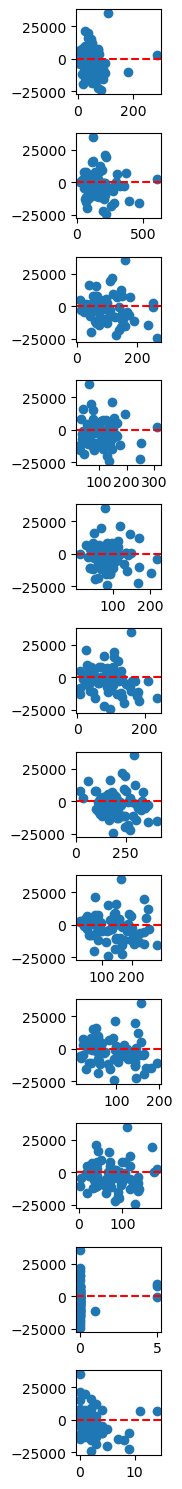

In [37]:
import matplotlib as mpl

residuals = y_test.copy()
residuals['residuals'] = residuals['mins delayed'] - pd.Series(ridge_pred, index=residuals.index)

fig, axs = plt.subplots(ncols=1, nrows=12, figsize=(15,15)
    )
mpl.rcParams['axes.labelsize'] = 8

for feat in enumerate(features):
        axs[feat[0]].set_box_aspect(aspect=1)
        axs[feat[0]].scatter(X_test[ feat[1]  ], residuals['residuals'])
        axs[feat[0]].axhline(0, color='r', linestyle='--')    
    
# for row in range(4):
#     for col in range(3):
#         axs[row, col].scatter(X_test[ features[ row + col ]], residuals['residuals'])
#         axs[row, col].axhline(0, color='r', linestyle='--')


plt.tight_layout()
plt.show()

## What's next? 

If we agree that total accumulated minutes delayed for a given day is our target, this notebook provides a toy model with an RMSE of around 10272. This is an improvement on the baseline RMSE (given by the standard deviation) of ~18906.5.

This toy model gives us a concrete benchmark for model evaluation. Assuming that we will stick with this target of total accumulated delay minutes for a day, a better model should ultimately beat an RMSE of around 10272. 

### Directions to consider: 

There seem to be two main directions of consideration, when it comes to improving this toy model. 

1) Sticking to these features, how can we improve this RMSE?
2) Using possibly a different set of features, can we improve this RMSE?
3) Using a different fitting algorithm, can we improve this RMSE? 

If we agree that total accumulated minutes delayed for a given day is our target, this notebook provides a toy model with an RMSE of around 10272. This is an improvement on the baseline RMSE (given by the standard deviation) of ~18906.5.

This toy model gives us a concrete benchmark for model evaluation. Assuming that we will stick with this target of total accumulated delay minutes for a day, a better model should ultimately beat an RMSE of around 10272. 

#### <u>1:</u>

While linear regression on bunching and gapping seems to model minutes delayed quite well in a certain range of the data, 
the model is improved by incorporating multiple influencing factors such as amount of snow on the ground and number of alerts in the TTC system for that day. By incorporating more influencing factors into the model, we can perhaps improve the RMSE. 

One easy area to consider that would most definitely be an influencing factor is location of bunching/gapping incidents. Unfortunately, in my primary scraping of the data, I neglected to record the stops that the datapoints belonged to.. I should rebuild the dataset with the stop information recorded and that will probably improve the model.


#### <u>2:</u>

It is possible that we can find a better signal from a different set of features. In this direction, we should consider features that are attainable if one wishes to deploy a model in a realistic setting. Modelling minutes delayed by considering bunching and gapping incidents may be useful for transit policy making -- this model suggests that minimizing bunching and gapping may improve the overall delays (in minutes) in the system. Given a number of bunching incidents and gapping incidents in a day, we have an estimate on the number of minutes the 506 streetcar will be delayed that day.

#### <u>3:</u>

As far as modelling minutes delayed with bunching and gapping incidents go, it does seem to be fairly linear. I am not sure if it is necessary to go beyond linear regression for this set of features. If we choose to go with another set of features, we can consider different fitting algorithms. Perhaps we can how factoring in the stop location information will play out.
